In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from importlib import reload
import prepare_data as pda
reload(pda)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dhaaa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhaaa\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


<module 'prepare_data' from 'c:\\Users\\dhaaa\\OneDrive\\Skrivebord\\Skole\\Gruppe INFO284\\Info284\\prepare_data.py'>

In [10]:
dataset = pd.read_csv("./data/Hotel_Reviews.csv")

X, y = pda.prepare_nlp(dataset)

KeyboardInterrupt: 

In [9]:
cv = CountVectorizer()
X = cv.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

AttributeError: 'csr_matrix' object has no attribute 'lower'

In [4]:
bnb = BernoulliNB(binarize=0)
model = bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print("BernoulliNB: ")
print(classification_report(y_test, y_pred))

BernoulliNB: 
              precision    recall  f1-score   support

    negative       0.20      0.24      0.22      2113
     neutral       0.61      0.50      0.55     33825
    positive       0.78      0.85      0.82     67210

    accuracy                           0.72    103148
   macro avg       0.53      0.53      0.53    103148
weighted avg       0.71      0.72      0.72    103148



MultinomialNB: 
              precision    recall  f1-score   support

    negative       0.35      0.18      0.24      2113
     neutral       0.64      0.63      0.64     33825
    positive       0.82      0.84      0.83     67210

    accuracy                           0.76    103148
   macro avg       0.61      0.55      0.57    103148
weighted avg       0.75      0.76      0.76    103148



<Axes: >

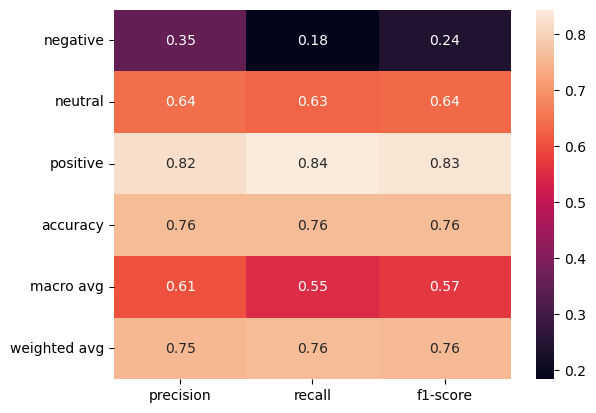

In [6]:
print("MultinomialNB: ")
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test) 
clf_report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

sb.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True)